In [14]:
!pip install --upgrade tensorflow


In [3]:
from google.colab import drive
drive.mount('/content/ColabNotebooks/')

Mounted at /content/ColabNotebooks/


In [4]:
import pandas as pd
import numpy as np


In [5]:
data_path = '/content/ColabNotebooks/MyDrive/ColabNotebooks/FB.csv'
fb_complete_data = pd.read_csv(data_path)
fb_complete_data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-05-18,42.049999,45.000000,38.000000,38.230000,38.230000,573576400
1,2012-05-21,36.529999,36.660000,33.000000,34.029999,34.029999,168192700
2,2012-05-22,32.610001,33.590000,30.940001,31.000000,31.000000,101786600
3,2012-05-23,31.370001,32.500000,31.360001,32.000000,32.000000,73600000
4,2012-05-24,32.950001,33.209999,31.770000,33.029999,33.029999,50237200


In [6]:
fb_training_process = fb_complete_data[['Open']].values

In [7]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
fb_training_scale = scaler.fit_transform(fb_training_process)

In [8]:
len(fb_training_scale)
fb_training_features = []
fb_training_labels =[]

for i in range(60, len(fb_training_scale)):
  fb_training_features.append(fb_training_scale[i-60:i,0])
  fb_training_labels.append(fb_training_scale[i,0])

In [9]:
X_train = np.array(fb_training_features)
y_train = np.array(fb_training_labels)

In [10]:
print(X_train.shape)
print(y_train.shape)

(2419, 60)
(2419,)


In [11]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1],1))

In [12]:
X_train.shape

(2419, 60, 1)

In [22]:
from re import VERBOSE
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Activation , Dense, Flatten, LSTM, Dropout, Flatten
from tensorflow.keras.models import Model

input_layer = Input(shape = (X_train.shape[1],1))
lstm1 = LSTM(100, activation = 'relu' , return_sequences = True) (input_layer)
do1 = Dropout(0.2)(lstm1)
lstm2 = LSTM(100, activation = 'relu' , return_sequences = True) (do1)
do2 = Dropout(0.2)(lstm2)
lstm3 = LSTM(100, activation = 'relu' , return_sequences = True) (do2)
do3 = Dropout(0.2)(lstm3)
lstm4 = LSTM(100, activation = 'relu' ) (do3)
do4 = Dropout(0.2)(lstm4)

output_layer = Dense(1)(do4)
model = Model(input_layer, output_layer)
model.compile(optimizer='adam', loss='mse')

print(X_train.shape)
print(y_train.shape)
y_train = y_train.reshape(-1,1)
print(y_train.shape)

model_history = model.fit(X_train, y_train, epochs=100 , verbose=1, batch_size=32)



(2419, 60, 1)
(2419, 1)
(2419, 1)
Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 26s 225ms/step - loss: 0.0221
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 219ms/step - loss: 0.0033
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 221ms/step - loss: 0.0031
Epoch 4/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - loss: 0.0028
Epoch 5/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 216ms/step - loss: 0.0023
Epoch 6/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 215ms/step - loss: 0.0023
Epoch 7/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step - loss: 0.0023
Epoch 8/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - loss: 0.0025
Epoch 9/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - loss: 0.0022
Epoch 10/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 237ms/step - loss: 0.0023
Epoch 11/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 221ms/step - loss: 0.0020
Epoch 12/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 17s 220ms/step - loss: 0.0019
Epoch 13/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 227ms/step - loss: 0.0017
Epoch 14/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 24s 317ms/step - loss: 0.

In [24]:

test_data_path = '/content/ColabNotebooks/MyDrive/ColabNotebooks/fb_test.csv'
fb_testing_complete_data = pd.read_csv(test_data_path)
fb_testing_processed = fb_testing_complete_data[['Open']].values
fb_all_data = pd.concat((fb_complete_data['Open'], fb_testing_complete_data['Open']), axis=0)
test_inputs = fb_all_data[len(fb_all_data) - len(fb_testing_complete_data) - 60:].values
print(test_inputs.shape)
test_inputs = test_inputs.reshape(-1,1)
test_inputs = scaler.transform(test_inputs)
print(test_inputs.shape)


(313,)
(313, 1)


In [25]:
fb_test_features = []
for i in range(60, len(test_inputs)):
  fb_test_features.append(test_inputs[i-60:i,0])

X_test = np.array(fb_test_features)
print(X_test.shape)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1],1))
print(X_test.shape)

(253, 60)
(253, 60, 1)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step


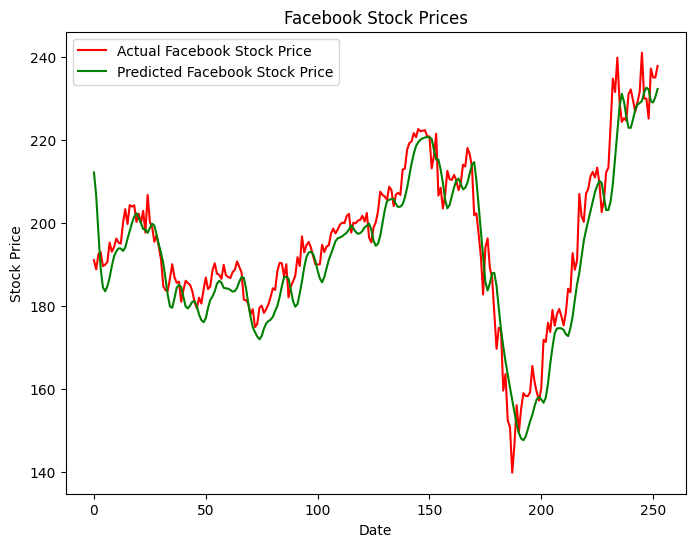

In [26]:
y_pred = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred)
plt.figure(figsize=(8,6))
plt.plot(fb_testing_processed, color='red' , label='Actual Facebook Stock Price' )
plt.plot(y_pred , color='green' , label='Predicted Facebook Stock Price' )
plt.title('Facebook Stock Prices' )
plt.xlabel('Date' )
plt.ylabel('Stock Price' )
plt.legend()
plt.show()